# 따릉이 수요 예측 — Weekday SARIMA/ARIMAX Pipeline
- 데이터: 2023~2025년 따릉이 대여 이력 (평일)
- 외생변수: 기온(℃), 강수여부(binary, 1mm 기준)
- 계절 주기: S=24 (시간 단위 → 일 주기)

## 1. 라이브러리 로드 및 설정

In [33]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy.stats import jarque_bera, shapiro
from sklearn.metrics import mean_squared_error, mean_absolute_error


sys.path.insert(0, str(Path('..').resolve()))

plt.rcParams['figure.dpi']   = 120
plt.rcParams['font.family']  = 'DejaVu Sans'

In [2]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path("..").resolve()))

## 2. 설정값 및 데이터 로드

In [41]:
# 설정값
DATA_DIR        = Path("../data")   # interpolated_available_YYYYMM.csv
SEASONAL_PERIOD = 24             # 일일 계절 주기 (시간 단위 → S=24)
TEST_DAYS       = 30             # 마지막 30일을 test set으로 사용
TARGET_RENT_ID  = "02171"           # 분석할 정류소 ID (정수형), 가장 수요가 많길래 이거부터 진행함
ALPHA = 1.5

In [15]:
from src.config import DATA_DIR, SEASONAL_PERIOD, TEST_DAYS, LONG_MISSING
# ALPHA, TARGET_RENT_ID, 는 포함 안함. 내가 임의로 돌리기 위해
from src.utils import (
    load_filtered_csvs, make_series, 
    load_weather, load_rainfall_binary,
    adf_test, diagnose_residuals, asymmetric_rmse, evaluate_forecast,
)

df_raw = load_filtered_csvs(DATA_DIR)

# 2023~2025년만 사용
df_raw = df_raw[df_raw['datetime'].dt.year >= 2023]

print(f'Data range : {df_raw["datetime"].min().date()} ~ {df_raw["datetime"].max().date()}')
print(f'Stations   : {df_raw["RENT_ID"].nunique()}')


Data range : 2023-01-01 ~ 2025-12-31
Stations   : 23


In [16]:
top_station = (
    df_raw.groupby("RENT_ID")["CNT"]
    .sum()
    .sort_values(ascending=False)
)
print(top_station.head(10))

RENT_ID
02171    49288
02179    39935
02111    37929
03311    33205
02191    29726
02112    29504
02185    28119
02148    25269
02116    23902
02198    23192
Name: CNT, dtype: int64


## 3. 데이터 전처리
**결측치 처리 전략** (`missing_value_report.md` 기준)
- 단기 (1~3일): 선형 보간
- 중기 (4~14일): 동일 요일+시간대 평균 대체  
- 장기 (15일 이상): NaN 유지 → 학습 윈도우에서 제외

In [17]:
series = make_series(df_raw, TARGET_RENT_ID)
print(f"정류소 {TARGET_RENT_ID} 시계열: {len(series):,}시간")
print(f"기간: {series.index[0]} ~ {series.index[-1]}")
print(f"결측 수: {series.isna().sum()}")
series.head(10)

정류소 02171 시계열: 26,302시간
기간: 2023-01-01 01:00:00 ~ 2025-12-31 22:00:00
결측 수: 0


2023-01-01 01:00:00    1.0
2023-01-01 02:00:00    1.0
2023-01-01 03:00:00    2.0
2023-01-01 04:00:00    0.0
2023-01-01 05:00:00    1.0
2023-01-01 06:00:00    0.0
2023-01-01 07:00:00    0.0
2023-01-01 08:00:00    0.0
2023-01-01 09:00:00    0.0
2023-01-01 10:00:00    1.0
Freq: h, Name: CNT, dtype: float64

평일 데이터: 18,791시간
주말 데이터: 7,511시간


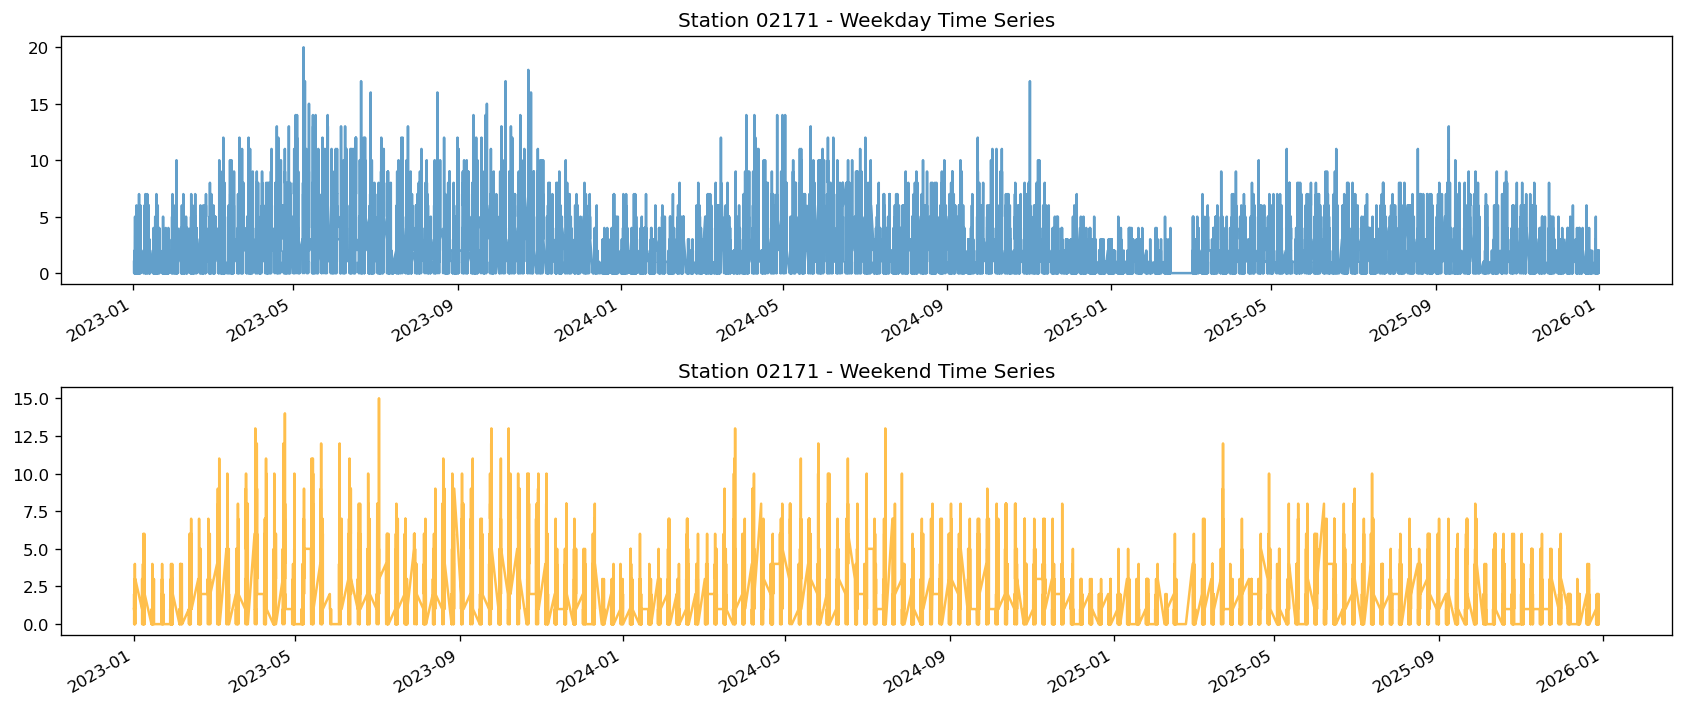

In [18]:
# 평일 / 주말 분리
series_weekday = series[series.index.dayofweek < 5]
series_weekend = series[series.index.dayofweek >= 5]

print(f"평일 데이터: {len(series_weekday):,}시간")
print(f"주말 데이터: {len(series_weekend):,}시간")

# 시각화
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=False)
series_weekday.plot(ax=axes[0], title=f"Station {TARGET_RENT_ID} - Weekday Time Series", alpha=0.7)
series_weekend.plot(ax=axes[1], title=f"Station {TARGET_RENT_ID} - Weekend Time Series", color="orange", alpha=0.7)
plt.tight_layout()
plt.show()

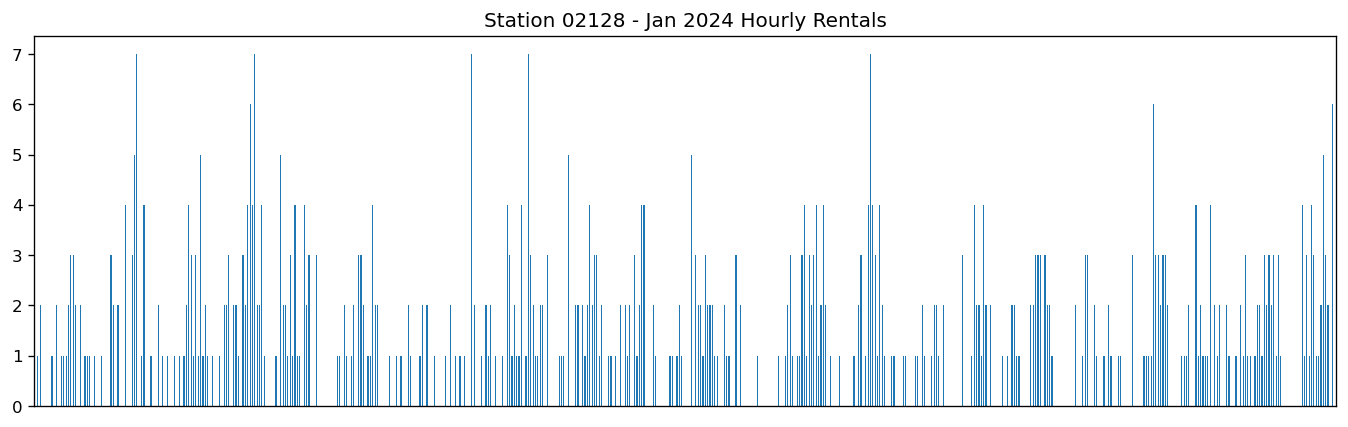

In [19]:
series_weekday["2024-01"].plot(
    kind="bar", figsize=(14, 4),
    title="Station 02128 - Jan 2024 Hourly Rentals"
)
plt.xticks([])  # x축 레이블 숨기기
plt.show()

In [21]:
# Train / Test Split — 평일 데이터 기준
target_series = series_weekday.dropna()

test_hours = TEST_DAYS * 24
train = target_series.iloc[:-test_hours]
test  = target_series.iloc[-test_hours:]

print(f"Train: {train.index[0]} ~ {train.index[-1]} ({len(train):,}시간)")
print(f"Test : {test.index[0]} ~ {test.index[-1]} ({len(test):,}시간)")

Train: 2023-01-02 00:00:00 ~ 2025-11-19 22:00:00 (18,071시간)
Test : 2025-11-19 23:00:00 ~ 2025-12-31 22:00:00 (720시간)


## 4. 정상성 검정 — ADF Test
- $H_0$: 단위근 존재 (non-stationary)  
- $H_1$: 단위근 없음 (stationary)  
- p-value < 0.05이면 정상성 확보


In [22]:
print("=" * 50)
is_stationary = adf_test(train, name=f"Station {TARGET_RENT_ID} (raw)")

if not is_stationary:
    print(f"\nS={SEASONAL_PERIOD} 계절 차분 후 재검정...")
    train_diff = train.diff(SEASONAL_PERIOD).dropna()
    print("=" * 50)
    adf_test(train_diff, name=f"Station {TARGET_RENT_ID} (after seasonal diff)")
else:
    train_diff = train

[ADF Test] Station 02171 (raw)
  ADF Statistic : -43.3373
  p-value       : 0.0000
  Critical (1%) : -3.4307
  Critical (5%) : -2.8617
  결론          : 정상 (stationary)


## 5. ACF / PACF 시각화
차수 후보 파악: ACF → MA 차수, PACF → AR 차수


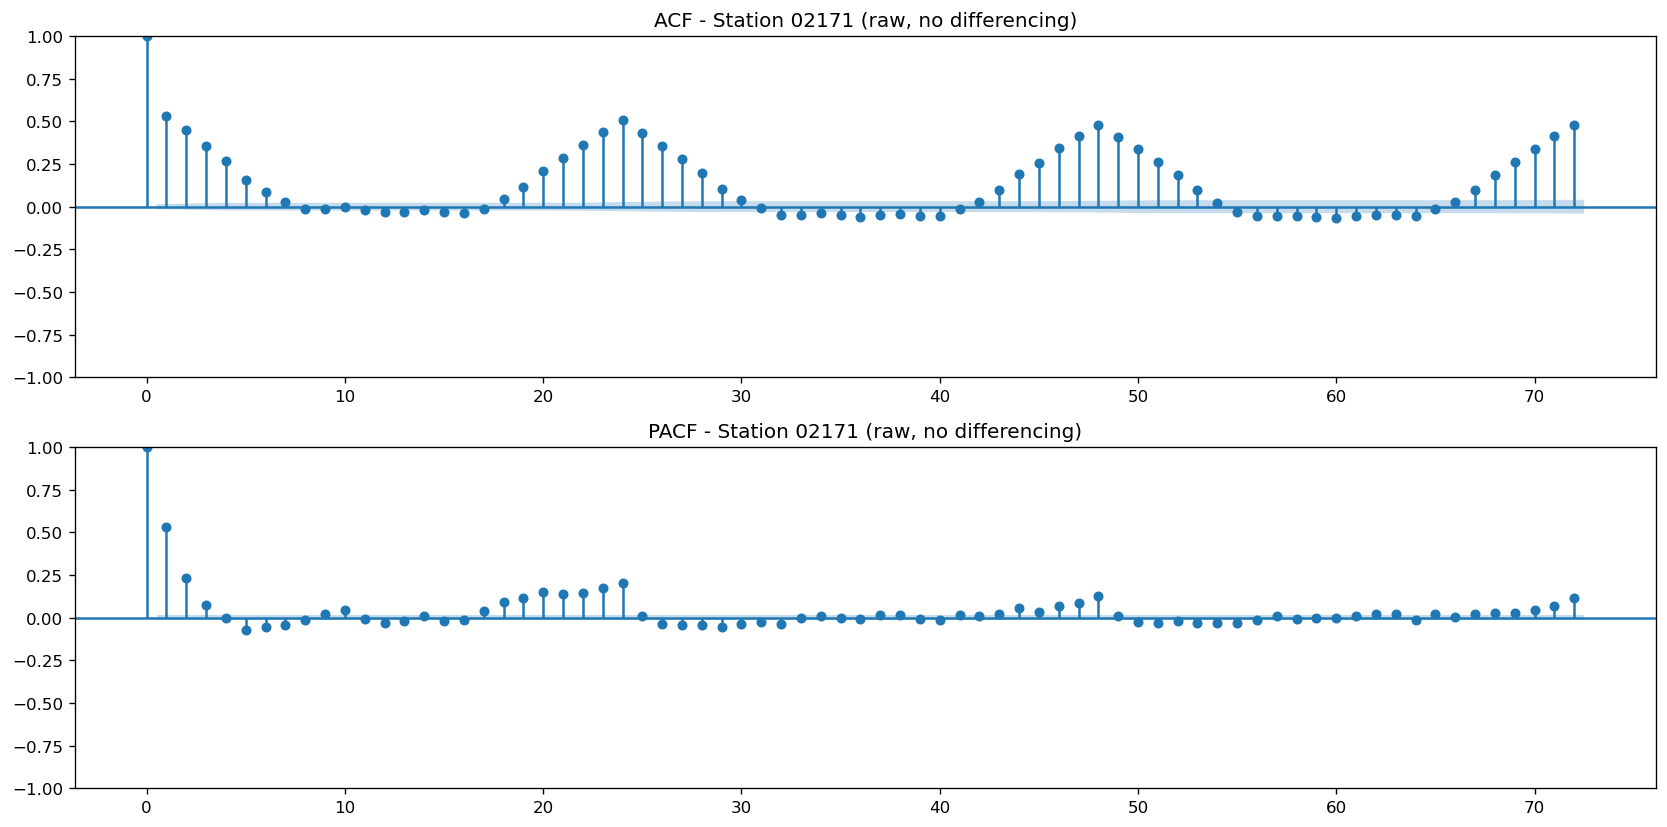

In [27]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7))
plot_acf(train_diff.dropna(), lags=72, ax=axes[0],
         title=f"ACF - Station {TARGET_RENT_ID} (raw, no differencing)")
plot_pacf(train_diff.dropna(), lags=72, ax=axes[1],
          title=f"PACF - Station {TARGET_RENT_ID} (raw, no differencing)")
plt.tight_layout()
plt.show()

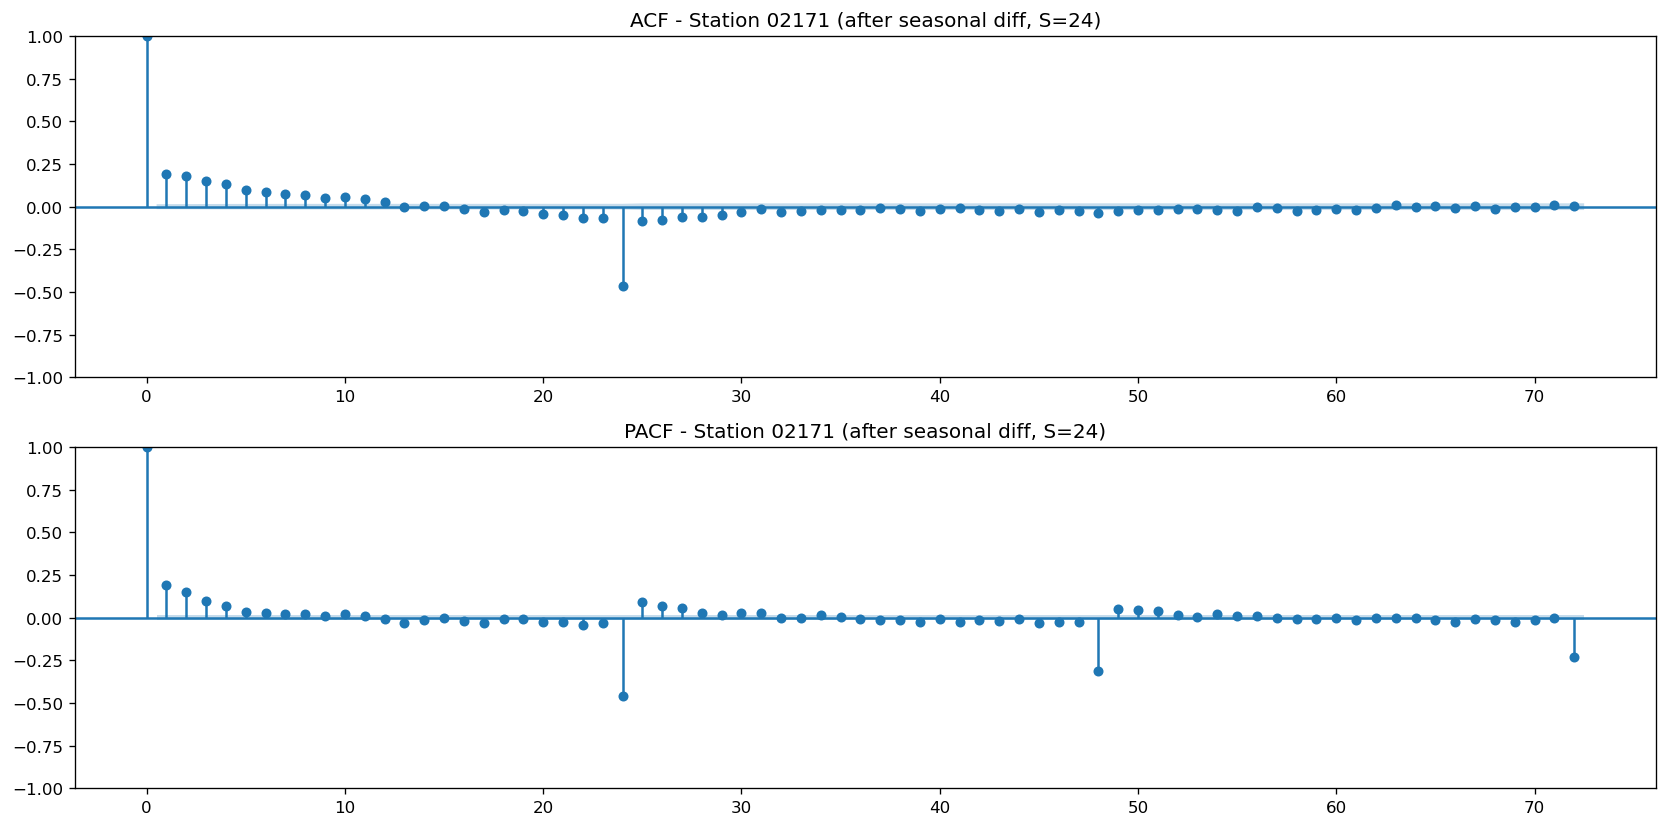

In [28]:
# ADF는 정상으로 판정했으나 계절성이 남아있으므로
# 계절 차분(D=1, S=24) 후 ACF/PACF로 차수 후보 파악
train_diff_seasonal = train.diff(SEASONAL_PERIOD).dropna()

fig, axes = plt.subplots(2, 1, figsize=(14, 7))
plot_acf(train_diff_seasonal,  lags=72, ax=axes[0],
         title=f"ACF - Station {TARGET_RENT_ID} (after seasonal diff, S=24)")
plot_pacf(train_diff_seasonal, lags=72, ax=axes[1],
          title=f"PACF - Station {TARGET_RENT_ID} (after seasonal diff, S=24)")
plt.tight_layout()
plt.show()

## 6. SARIMA 모델 적합
`statsforecast AutoARIMA`로 AIC 기준 최적 차수 자동 선택
계절 주기 **S=24** (시간 단위 데이터 → 하루 주기)

pmdarima는 5년치 시간 단위 데이터에서 메모리 부족 문제가 발생하므로,
Cython 기반의 statsforecast AutoARIMA를 별도 스크립트로 실행하여 차수를 탐색한다.

In [34]:
# 차수 탐색
%run ../scripts/sarima_auto_arima_weekday.py

# 탐색 결과 자동으로 받아서 적합
order          = BEST_ORDER
seasonal_order = BEST_SEASONAL_ORDER
print(f"Using order: ARIMA{order}x{seasonal_order}")

sarima_model = SARIMAX(
    train,
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False,
)
sarima_fit = sarima_model.fit(disp=False)
print(sarima_fit.summary())

Data range : 2023-01-01 ~ 2025-12-31
Weekday train : 2023-01-02 ~ 2025-12-31  (18,789 hours)

Running statsforecast AutoARIMA...

ARIMA(2,0,2)(1,1,1)[24] with drift        :inf

ARIMA(0,0,0)(0,1,0)[24] with drift        :61775.36122393714

ARIMA(1,0,0)(1,1,0)[24] with drift        :56316.090459454594

ARIMA(0,0,1)(0,1,1)[24] with drift        :inf

ARIMA(0,0,0)(0,1,0)[24]                   :61782.75182143509

ARIMA(1,0,0)(0,1,0)[24] with drift        :61673.11362732175

ARIMA(1,0,0)(2,1,0)[24] with drift        :53939.487369142036

ARIMA(1,0,0)(2,1,1)[24] with drift        :inf

ARIMA(1,0,0)(1,1,1)[24] with drift        :inf

ARIMA(0,0,0)(2,1,0)[24] with drift        :54072.619814012025

ARIMA(2,0,0)(2,1,0)[24] with drift        :53803.88255911502

ARIMA(2,0,0)(1,1,0)[24] with drift        :56185.99909390164

ARIMA(2,0,0)(2,1,1)[24] with drift        :inf

ARIMA(2,0,0)(1,1,1)[24] with drift        :inf

ARIMA(2,0,1)(2,1,0)[24] with drift        :53623.906923725976

ARIMA(2,0,1)(1,1,0)[

## 7. ARIMAX 모델 적합
기상 데이터(기온, 강수량)를 외생변수로 추가  
기상청 데이터 수집 후 `weather.csv`로 저장하여 사용


In [29]:
# load_rainfall_binary: 기온 + rain_binary(1mm 기준) 반환
# 동절기(11~3월) 결측 → 앞뒤 3시간 이내 관측값이 둘 다 1일 때만 1, 나머지 0
# 하절기(4~10월) 결측 → 0 (보수적 처리)
weather_df = load_rainfall_binary(DATA_DIR, threshold=1.0)

exog_train = weather_df.loc[weather_df.index.isin(train.index)][['temp', 'rain_binary']]
exog_test  = weather_df.loc[weather_df.index.isin(test.index)][['temp', 'rain_binary']]

print(f'Exog train shape: {exog_train.shape}')
print(f'Missing in exog_train: {exog_train.isna().sum().to_dict()}')
exog_train.head()

Exog train shape: (18071, 2)
Missing in exog_train: {'temp': 0, 'rain_binary': 0}


,temp,rain_binary
datetime,,
2023-01-02 00:00:00,-4.3,0
2023-01-02 01:00:00,-5.0,0
2023-01-02 02:00:00,-5.6,0
2023-01-02 03:00:00,-6.2,0
2023-01-02 04:00:00,-6.6,0


In [35]:
# ARIMAX 적합

arimax_model = SARIMAX(
    train,
    exog=exog_train,
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False,
)
arimax_fit = arimax_model.fit(disp=False)
print(arimax_fit.summary())

                                      SARIMAX Results                                      
Dep. Variable:                                 CNT   No. Observations:                18071
Model:             SARIMAX(1, 0, 2)x(2, 1, [], 24)   Log Likelihood              -35723.588
Date:                             Wed, 27 May 2026   AIC                          71463.176
Time:                                     03:00:39   BIC                          71525.560
Sample:                                          0   HQIC                         71483.691
                                           - 18071                                         
Covariance Type:                               opg                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
temp            0.0716      0.006     11.986      0.000       0.060       0.083
rain_binary    -1.0489  

In [46]:
# ARIMAX (강수여부만 외생변수)
exog_train_rain = exog_train[['rain_binary']]
exog_test_rain  = exog_test[['rain_binary']]

arimax_rain_model = SARIMAX(
    train,
    exog=exog_train_rain,
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False,
)
arimax_rain_fit = arimax_rain_model.fit(disp=False)
print(arimax_rain_fit.summary())

                                      SARIMAX Results                                      
Dep. Variable:                                 CNT   No. Observations:                18071
Model:             SARIMAX(1, 0, 2)x(2, 1, [], 24)   Log Likelihood              -35801.396
Date:                             Wed, 27 May 2026   AIC                          71616.793
Time:                                     03:20:18   BIC                          71671.379
Sample:                                          0   HQIC                         71634.743
                                           - 18071                                         
Covariance Type:                               opg                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
rain_binary    -1.0692      0.075    -14.208      0.000      -1.217      -0.922
ar.L1           0.8373  

## 8. 잔차 진단
| 검정 | 귀무가설 |
|------|----------|
| Ljung-Box | 잔차에 자기상관 없음 (백색잡음) |
| Jarque-Bera | 잔차가 정규분포를 따름 |
| Shapiro-Wilk | 잔차가 정규분포를 따름 |


  잔차 진단: SARIMA

[Ljung-Box Test] H0: 잔차에 자기상관 없음
       lb_stat      lb_pvalue
10   17.230553   6.941558e-02
20   34.533243   2.273584e-02
48  669.310296  2.214039e-110
  → 자기상관 존재

[Jarque-Bera Test] H0: 정규분포
  통계량=7326.6524, p-value=0.0000
  → 정규성 기각

[Shapiro-Wilk Test] H0: 정규분포
  통계량=0.9650, p-value=0.0000
  → 정규성 기각


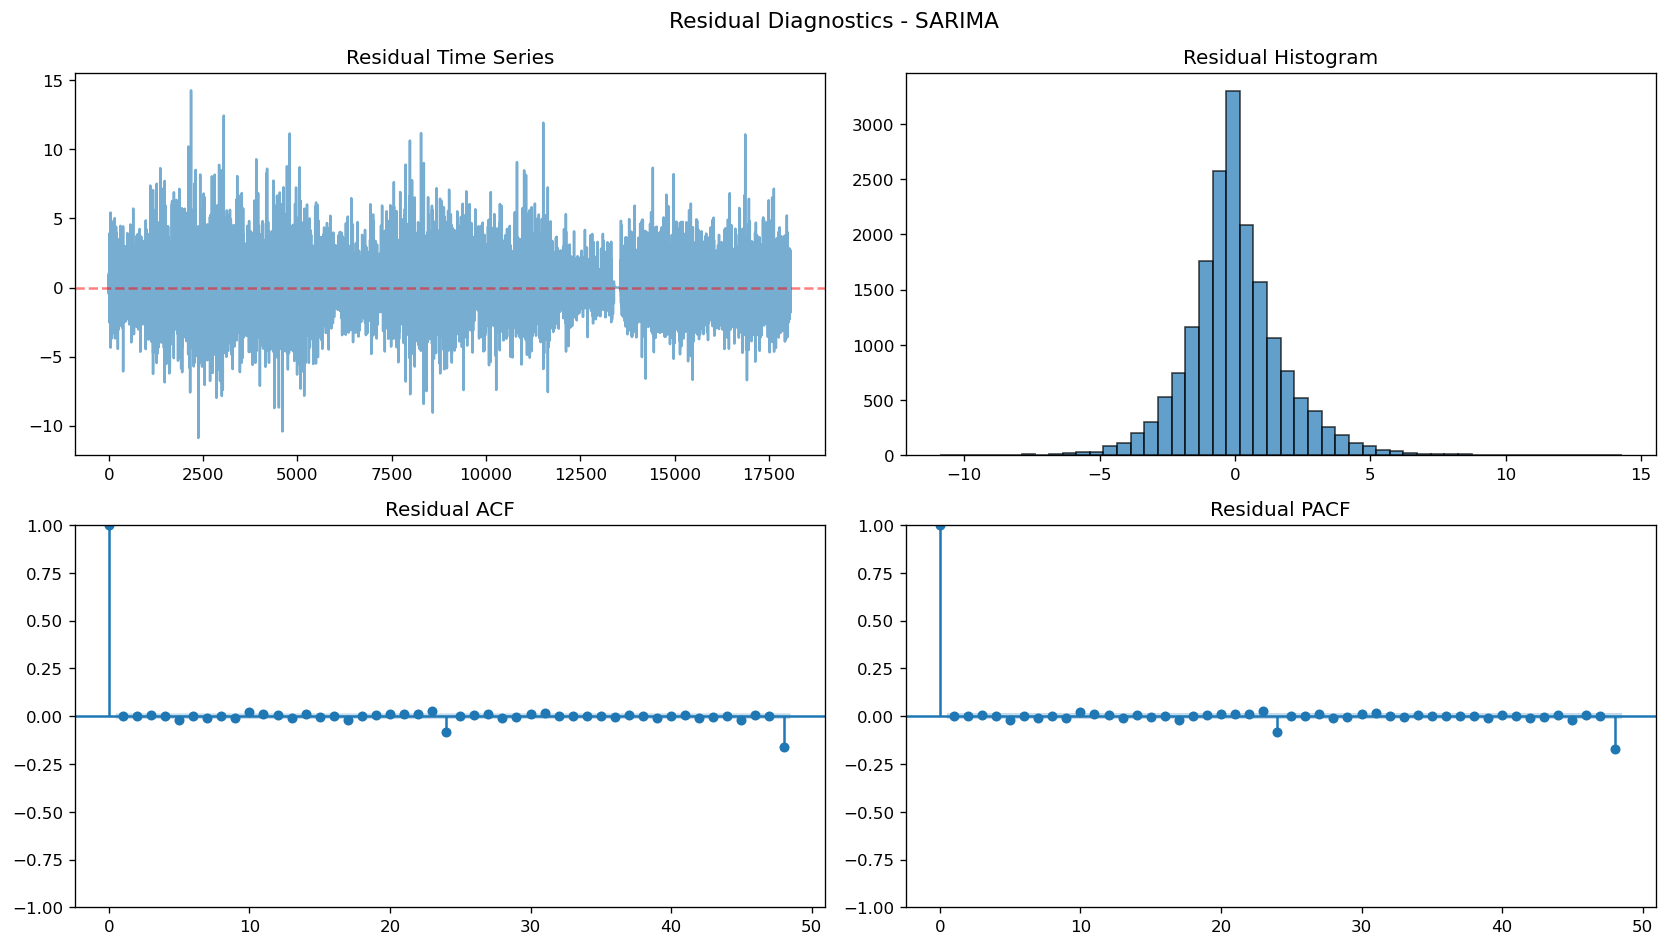

In [36]:
# SARIMA 잔차 진단
diag_sarima = diagnose_residuals(sarima_fit, model_name="SARIMA")

  잔차 진단: ARIMAX

[Ljung-Box Test] H0: 잔차에 자기상관 없음
       lb_stat      lb_pvalue
10   21.002872   2.107355e-02
20   42.209192   2.597076e-03
48  675.593750  1.185199e-111
  → 자기상관 존재

[Jarque-Bera Test] H0: 정규분포
  통계량=7534.0239, p-value=0.0000
  → 정규성 기각

[Shapiro-Wilk Test] H0: 정규분포
  통계량=0.9658, p-value=0.0000
  → 정규성 기각


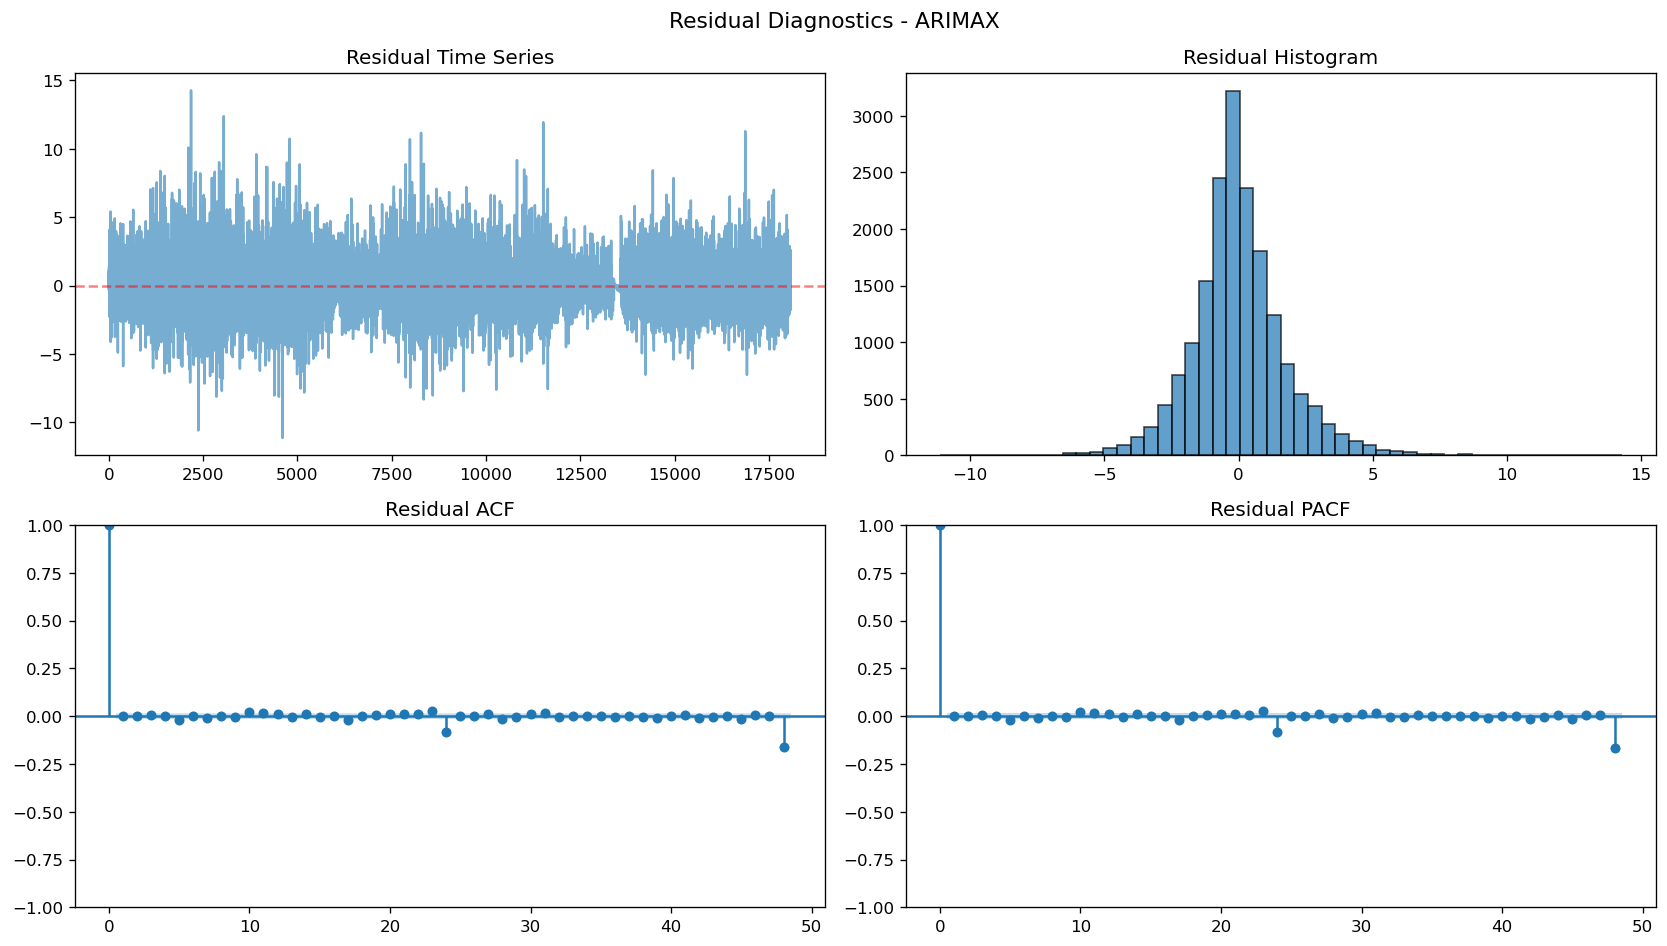

In [37]:
# ARIMAX 잔차 진단
diag_arimax = diagnose_residuals(arimax_fit, model_name="ARIMAX")

## 9. 예측 성능 평가

### 평가 지표
| 지표 | 설명 | 비고 |
|------|------|------|
| **RMSE** | 기본 예측 정확도, 큰 오차에 민감 | 주요 지표 |
| **MAE** | 평균 절대 오차, 이상치 영향 적음 | 보조 지표 |
| **Asymmetric RMSE** | 과소예측에 $\alpha$배 패널티 | 조교님 권장 |
| **과소예측 비율** | $\hat{y} < y$ 인 비율 | 자전거 고갈 위험도 |

### 비대칭 손실함수
$$L(\hat{y}, y) = \begin{cases} \alpha \cdot (\hat{y} - y)^2 & \text{if } \hat{y} < y \text{ (과소예측)} \\ (\hat{y} - y)^2 & \text{if } \hat{y} \geq y \text{ (과대예측)} \end{cases}$$

- $y$: 실제 대여 건수 (CNT)
- $\hat{y}$: 모델이 예측한 대여 건수
- $\alpha > 1$: 과소예측 패널티 가중치 (기본값 $\alpha=2$)


[SARIMA]
  RMSE              : 1.279
  MAE               : 0.930
  Asymmetric RMSE   : 1.378  (alpha=1.5)
  과소예측 비율      : 27.6%


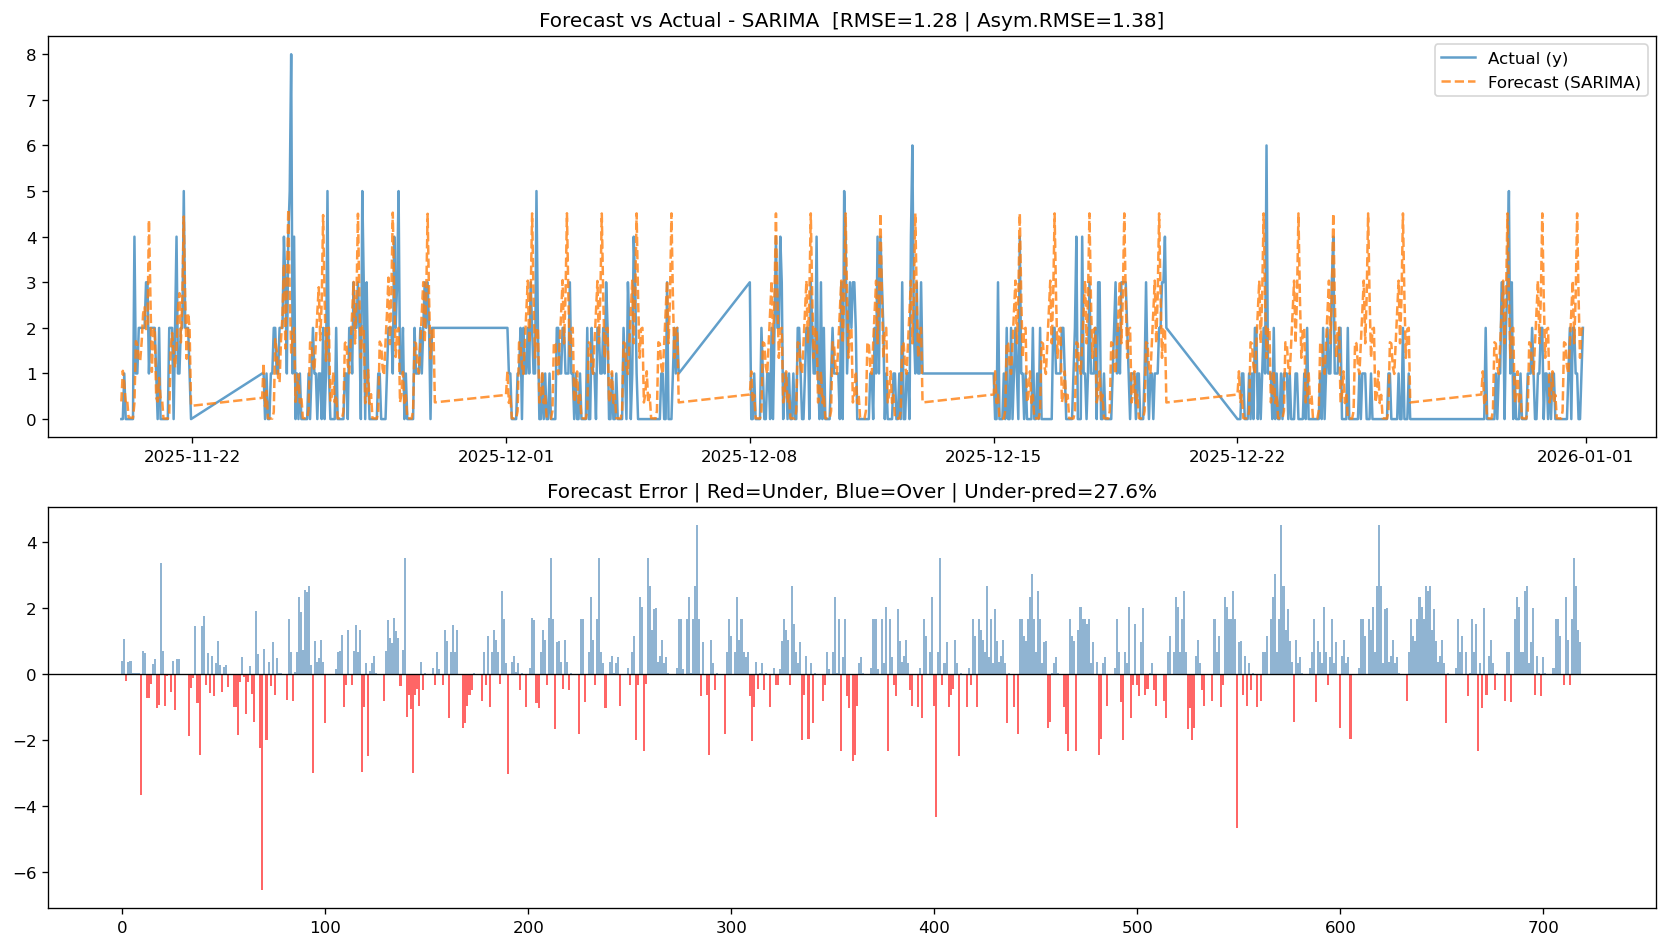

In [42]:
perf_sarima = evaluate_forecast(sarima_fit, test, model_name="SARIMA", alpha=ALPHA)

[ARIMAX]
  RMSE              : 1.207
  MAE               : 0.915
  Asymmetric RMSE   : 1.307  (alpha=1.5)
  과소예측 비율      : 37.1%


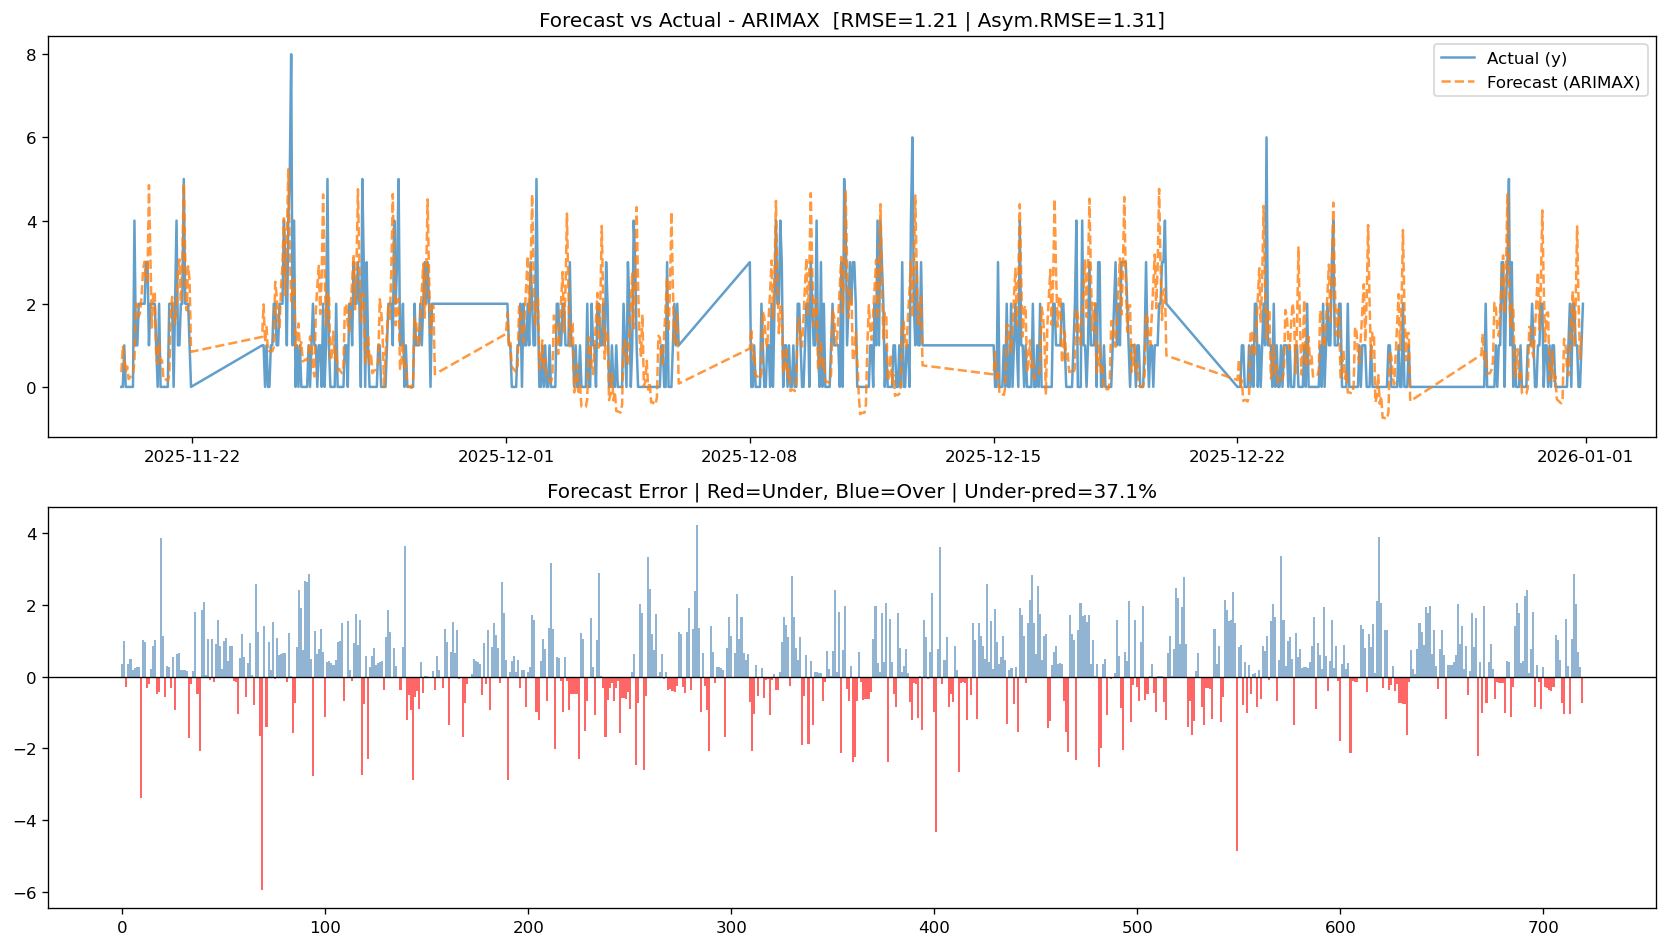

In [43]:
perf_arimax = evaluate_forecast(arimax_fit, test, model_name="ARIMAX",
                                exog_test=exog_test, alpha=ALPHA)

[ARIMAX (rain only)]
  RMSE              : 1.262
  MAE               : 0.918
  Asymmetric RMSE   : 1.364  (alpha=1.5)
  과소예측 비율      : 29.2%


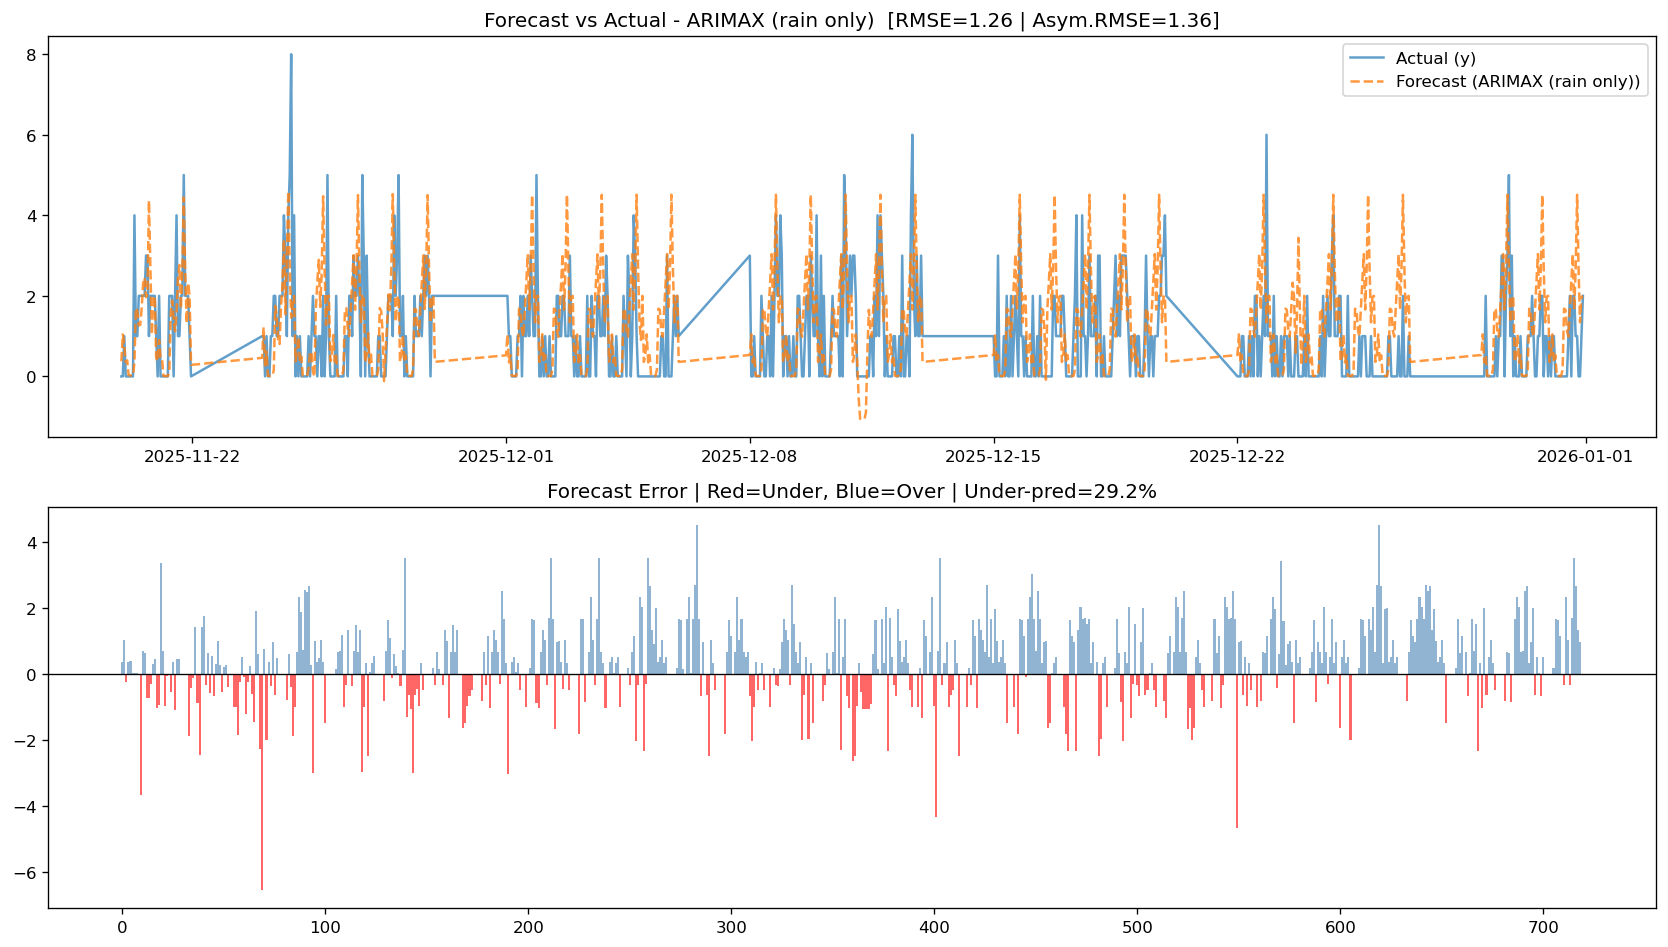

In [49]:
perf_arimax_rain = evaluate_forecast(arimax_rain_fit, test, model_name='ARIMAX (rain only)',
                                     exog_test=exog_test_rain, alpha=ALPHA)

  잔차 진단: ARIMAX

[Ljung-Box Test] H0: 잔차에 자기상관 없음
       lb_stat      lb_pvalue
10   17.375595   6.645529e-02
20   35.802868   1.622219e-02
48  672.789841  4.377651e-111
  → 자기상관 존재

[Jarque-Bera Test] H0: 정규분포
  통계량=7446.9221, p-value=0.0000
  → 정규성 기각

[Shapiro-Wilk Test] H0: 정규분포
  통계량=0.9653, p-value=0.0000
  → 정규성 기각


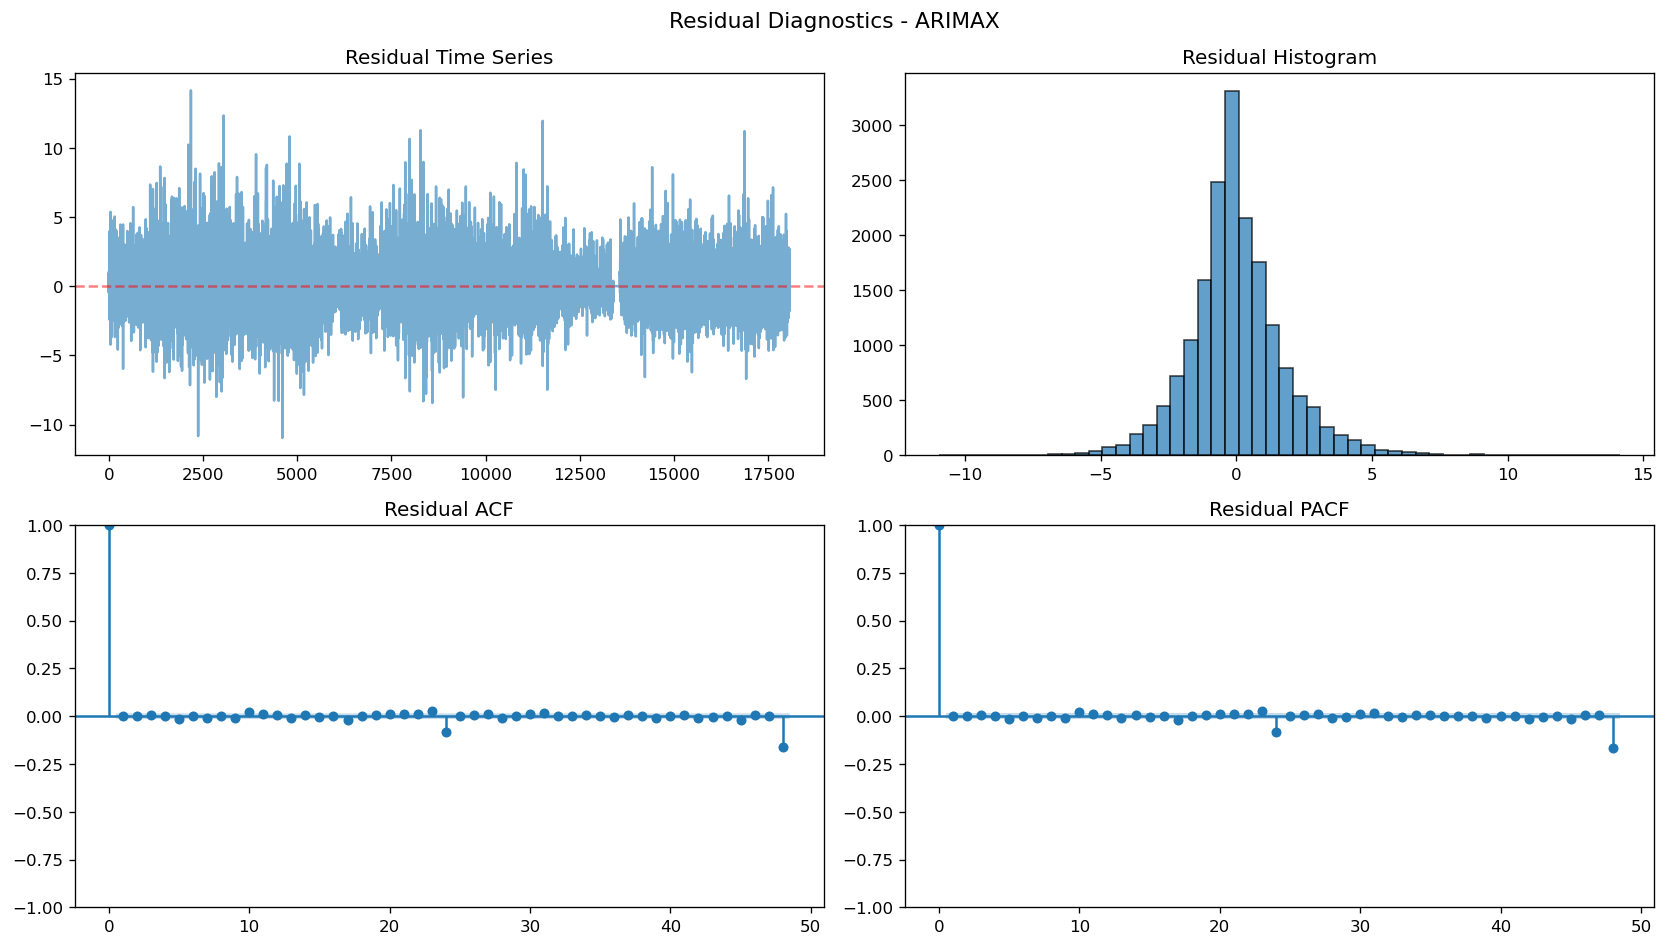

In [51]:
# ARIMAX 잔차 진단 (강수량만)
diag_arimax_rain = diagnose_residuals(arimax_rain_fit, model_name="ARIMAX")

## 10. 모델 성능 비교


         Model Performance Comparison
                     RMSE    MAE  Asym.RMSE(α=1.5)  과소예측비율(%)
model                                                        
SARIMA              1.279  0.930             1.378       27.6
ARIMAX              1.207  0.915             1.307       37.1
ARIMAX (rain only)  1.262  0.918             1.364       29.2


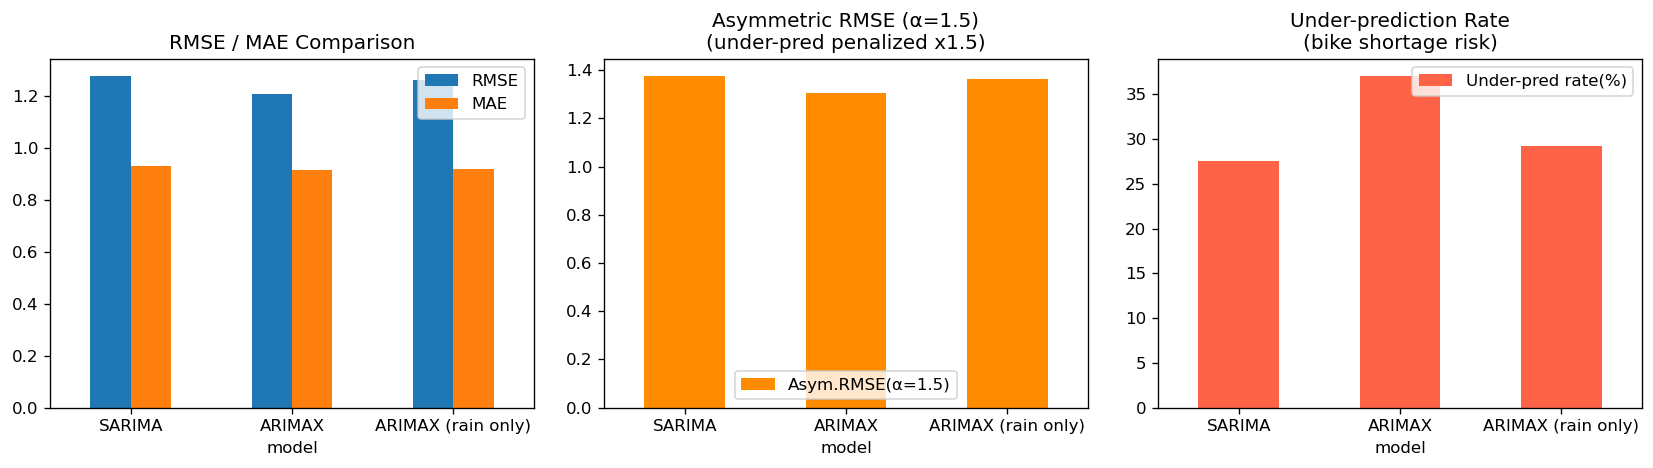

In [50]:
result_df = pd.DataFrame([perf_sarima, perf_arimax, perf_arimax_rain]).set_index("model")
print("\n" + "="*55)
print("         Model Performance Comparison")
print("="*55)
print(result_df.to_string())

# Visualization
asym_col = f"Asym.RMSE(α={ALPHA})"
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

result_df[["RMSE", "MAE"]].plot(kind="bar", ax=axes[0],
    title="RMSE / MAE Comparison", rot=0)

result_df[[asym_col]].plot(kind="bar", ax=axes[1],
    title=f"Asymmetric RMSE (α={ALPHA})\n(under-pred penalized x{ALPHA})", rot=0, color="darkorange")

result_df[["과소예측비율(%)"]].rename(
    columns={"과소예측비율(%)": "Under-pred rate(%)"}
).plot(kind="bar", ax=axes[2],
    title="Under-prediction Rate\n(bike shortage risk)", rot=0, color="tomato")

plt.tight_layout()
plt.show()